In [1]:
# Parameters
# Refer to injected parameters for any run.ipynb (similar cell below)
fname = 'BY4741_FKS1-HS1_single_ortho_caspofungin'

# Notebook to generate heatmaps

## Import libraries

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams['svg.fonttype'] = 'none'

## Specify paths

In [3]:
variantdata_path = 'dimsum_output/variant_data/'
processed_data_outpath = 'processed_data/'
aggdata_outpath = 'aggregated_data/'
heatmapdata_outpath = 'heatmaps_data/'
mgraph_outpath = 'manuscript_figures/'

## Get conditions from filename

In [4]:
f = variantdata_path + fname
pos_offset = {'FKS1-HS1': 639,
              'FKS1-HS2': 1353,
              'FKS1-HS3': 690,
              'FKS2-HS1': 659,
              'FKS2-HS2': 1372
             }

In [5]:
cset = f.split('/')[-1].split('_') # Extract conditions from parameter
cset_name = '_'.join(cset) # Basename based on conditions
strain, locus, pool_type, compound = [cset[i] for i in (0,1,2,-1)]
print(f'Strain: {strain}')
print(f'Locus: {locus}')
print(f'Pool type: {pool_type}')
print(f'Compound: {compound}')

Strain: BY4741
Locus: FKS1-HS1
Pool type: single
Compound: caspofungin


In [6]:
if compound == 'none':
    thresh = -.7
    cax_label = 'del'
else:
    # Retrieve threshold value that classifies variants as resistant
    thresh_df = pd.read_csv(f"{aggdata_outpath}/classified_variants/{'_'.join(cset[:3])}/thresholds.csv", index_col=0)
    thresh = thresh_df.loc[(thresh_df.compound == compound) & (thresh_df.thresh == 'low'), 'val'].item()
    cax_label = 'res'

## Import dataframe

In [7]:
withSyndf = pd.read_csv(processed_data_outpath+cset_name+'/selcoeff_all_libraries.csv', index_col=0)
wtaa = withSyndf.loc[withSyndf.WT == True, 'aa_seq'].values[0]
withSyndf

,seq_type,nt_seq,aa_pos,alt_codons,mutated_codon,combination,aa_seq,WT,STOP,STOP_readthrough,...,b1_log10,b2_log10,b3_log10,alt_aa,mutation_type,Log2FC_1,Log2FC_2,selcoeff_1,selcoeff_2,median_s
0,single,aagttagttttatctttgagagatcca,0.0,aag,1.0,NaN,KLVLSLRDP,NaN,False,False,...,-2.336016,-2.238248,-2.289796,K,non-synonymous,0.229968,0.273581,1.377240,1.314719,1.345980
1,single,aatttagttttatctttgagagatcca,0.0,aat,1.0,NaN,NLVLSLRDP,NaN,False,False,...,-3.595389,-4.328153,-3.703248,N,non-synonymous,0.090703,-0.423904,1.237974,0.617235,0.927604
2,single,acgttagttttatctttgagagatcca,0.0,acg,1.0,NaN,TLVLSLRDP,NaN,False,False,...,-3.952900,-4.027123,-3.630698,T,non-synonymous,-0.220652,-0.121988,0.926619,0.919151,0.922885
3,single,actttagttttatctttgagagatcca,0.0,act,1.0,NaN,TLVLSLRDP,NaN,False,False,...,-2.083017,-2.071976,-2.055776,T,non-synonymous,0.228676,0.250397,1.375947,1.291535,1.333741
4,single,aggttagttttatctttgagagatcca,0.0,agg,1.0,NaN,RLVLSLRDP,NaN,False,False,...,-3.062044,-2.993197,-3.091429,R,non-synonymous,0.325885,0.307568,1.473156,1.348706,1.410931
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
521,WT,tttttagttttatctttgagagatcca,4.0,tct,NaN,NaN,FLVLSLRDP,True,NaN,NaN,...,NaN,NaN,NaN,S,synonymous,-0.990111,-1.064983,0.157160,-0.023844,0.066658
522,WT,tttttagttttatctttgagagatcca,5.0,ttg,NaN,NaN,FLVLSLRDP,True,NaN,NaN,...,NaN,NaN,NaN,L,synonymous,-0.990111,-1.064983,0.157160,-0.023844,0.066658
523,WT,tttttagttttatctttgagagatcca,6.0,aga,NaN,NaN,FLVLSLRDP,True,NaN,NaN,...,NaN,NaN,NaN,R,synonymous,-0.990111,-1.064983,0.157160,-0.023844,0.066658
524,WT,tttttagttttatctttgagagatcca,7.0,gat,NaN,NaN,FLVLSLRDP,True,NaN,NaN,...,NaN,NaN,NaN,D,synonymous,-0.990111,-1.064983,0.157160,-0.023844,0.066658


## Reshape dataframe

In [8]:
if pool_type == 'single':
    withWTdf = withSyndf[withSyndf.seq_type.isin(['WT','single'])]
else:
    withWTdf = withSyndf[withSyndf.Nham_aa <=1]
withWTdf

,seq_type,nt_seq,aa_pos,alt_codons,mutated_codon,combination,aa_seq,WT,STOP,STOP_readthrough,...,b1_log10,b2_log10,b3_log10,alt_aa,mutation_type,Log2FC_1,Log2FC_2,selcoeff_1,selcoeff_2,median_s
0,single,aagttagttttatctttgagagatcca,0.0,aag,1.0,NaN,KLVLSLRDP,NaN,False,False,...,-2.336016,-2.238248,-2.289796,K,non-synonymous,0.229968,0.273581,1.377240,1.314719,1.345980
1,single,aatttagttttatctttgagagatcca,0.0,aat,1.0,NaN,NLVLSLRDP,NaN,False,False,...,-3.595389,-4.328153,-3.703248,N,non-synonymous,0.090703,-0.423904,1.237974,0.617235,0.927604
2,single,acgttagttttatctttgagagatcca,0.0,acg,1.0,NaN,TLVLSLRDP,NaN,False,False,...,-3.952900,-4.027123,-3.630698,T,non-synonymous,-0.220652,-0.121988,0.926619,0.919151,0.922885
3,single,actttagttttatctttgagagatcca,0.0,act,1.0,NaN,TLVLSLRDP,NaN,False,False,...,-2.083017,-2.071976,-2.055776,T,non-synonymous,0.228676,0.250397,1.375947,1.291535,1.333741
4,single,aggttagttttatctttgagagatcca,0.0,agg,1.0,NaN,RLVLSLRDP,NaN,False,False,...,-3.062044,-2.993197,-3.091429,R,non-synonymous,0.325885,0.307568,1.473156,1.348706,1.410931
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
521,WT,tttttagttttatctttgagagatcca,4.0,tct,NaN,NaN,FLVLSLRDP,True,NaN,NaN,...,NaN,NaN,NaN,S,synonymous,-0.990111,-1.064983,0.157160,-0.023844,0.066658
522,WT,tttttagttttatctttgagagatcca,5.0,ttg,NaN,NaN,FLVLSLRDP,True,NaN,NaN,...,NaN,NaN,NaN,L,synonymous,-0.990111,-1.064983,0.157160,-0.023844,0.066658
523,WT,tttttagttttatctttgagagatcca,6.0,aga,NaN,NaN,FLVLSLRDP,True,NaN,NaN,...,NaN,NaN,NaN,R,synonymous,-0.990111,-1.064983,0.157160,-0.023844,0.066658
524,WT,tttttagttttatctttgagagatcca,7.0,gat,NaN,NaN,FLVLSLRDP,True,NaN,NaN,...,NaN,NaN,NaN,D,synonymous,-0.990111,-1.064983,0.157160,-0.023844,0.066658


### Import validation mutants missing from the dataset (only for BY FKS1-HS1)

In [9]:
rescued_df = pd.read_csv(f'{aggdata_outpath}/validation_DMS_missing_estimates.csv', index_col=0)[['genotype','compound','estimated_s']]
rescued_df.head(8)

,genotype,compound,estimated_s
8,F639C,anidulafungin,1.392582
9,F639C,caspofungin,1.329652
10,F639C,micafungin,1.345690
11,F639C,none,0.084872
32,L640D,anidulafungin,-0.007735
33,L640D,caspofungin,-0.053246
34,L640D,micafungin,0.489734
35,L640D,none,0.041897


### Pivot dataframe

In [10]:
withWTdf_gby = withWTdf.groupby(['alt_aa','aa_pos','nt_seq'])[['median_s','confidence_score']].first().reset_index()

In [11]:
aa_single = withWTdf_gby.groupby(['alt_aa','aa_pos'])[['median_s','confidence_score']].agg(median_s = ('median_s', 'median'),
                                                                                           cscore = ('confidence_score', 'min')
                                                                                          ).reset_index()
aa_single['aa_pos'] = aa_single['aa_pos'].astype(int) + pos_offset[locus]

In [12]:
aa_single

,alt_aa,aa_pos,median_s,cscore
0,*,639,0.178046,1.0
1,*,640,0.123031,1.0
2,*,641,-0.007840,1.0
3,*,642,0.268104,1.0
4,*,643,0.307138,1.0
...,...,...,...,...
179,Y,643,1.288236,1.0
180,Y,644,-0.082778,1.0
181,Y,645,-0.113897,1.0
182,Y,646,1.316024,1.0


In [13]:
if (strain == 'BY4741') & (locus == 'FKS1-HS1'):
    rescued_filtered = rescued_df[(rescued_df.compound == compound)
                                  & (rescued_df.genotype.isin(['F639C', 'L640D', 'L642G', 'P647N', 'P647Q']))
                                 ]
    rescued_filtered['wt_aa'], rescued_filtered['aa_pos'], rescued_filtered['alt_aa'] = zip(*rescued_filtered['genotype'].apply(lambda x: [x[0], int(x[1:-1]), x[-1]]))
    rescued_filtered.rename(columns={'estimated_s':'median_s'}, inplace=True)
else:
    rescued_filtered = pd.DataFrame([], columns=['alt_aa','aa_pos','median_s'])

/tmp/ipykernel_3133/3724626511.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rescued_filtered['wt_aa'], rescued_filtered['aa_pos'], rescued_filtered['alt_aa'] = zip(*rescued_filtered['genotype'].apply(lambda x: [x[0], int(x[1:-1]), x[-1]]))
/tmp/ipykernel_3133/3724626511.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rescued_filtered['wt_aa'], rescued_filtered['aa_pos'], rescued_filtered['alt_aa'] = zip(*rescued_filtered['genotype'].apply(lambda x: [x[0], int(x[1:-1]), x[-1]]))
/tmp/ipykernel_313

In [14]:
aa_single_complete = pd.concat([aa_single[aa_single.cscore < 3], rescued_filtered[['alt_aa','aa_pos','median_s']]], ignore_index=True)
aa_single_complete.to_csv(f'{heatmapdata_outpath}/{cset_name}.csv')
aa_single_complete

,alt_aa,aa_pos,median_s,cscore
0,*,639,0.178046,1.0
1,*,640,0.123031,1.0
2,*,641,-0.007840,1.0
3,*,642,0.268104,1.0
4,*,643,0.307138,1.0
...,...,...,...,...
183,C,639,1.329652,NaN
184,D,640,-0.053246,NaN
185,G,642,-0.027393,NaN
186,N,647,1.287539,NaN


In [15]:
wide_aa = aa_single_complete.pivot(index='alt_aa', columns='aa_pos', values='median_s')

aa_sort_order = '*PGCQNTSEDKHRWYFMLIVA'
aa_sort_dic = dict(zip(list(aa_sort_order), list(range(0,len(aa_sort_order)))))
wide_aa.sort_index(key=lambda x: x.map(aa_sort_dic), inplace=True)
wide_aa

aa_pos,639,640,641,642,643,644,645,646,647
alt_aa,,,,,,,,,
*,0.178046,0.123031,-0.007840,0.268104,0.307138,0.164167,0.185813,0.271439,0.298635
P,1.324361,0.072985,1.178173,-0.147505,1.344617,-0.010679,1.020236,1.326341,0.066658
G,1.392171,0.165532,0.337554,-0.027393,0.482284,-0.226851,1.317275,1.095020,1.186328
C,1.329652,-0.175540,-0.195920,0.121431,1.008396,0.045659,0.051809,1.339724,NaN
Q,1.369107,0.032541,-0.011358,-0.121033,1.322367,1.351571,0.005247,1.207148,1.339099
N,0.927604,-0.024581,0.893415,0.117234,1.361384,-0.095078,0.275132,0.708311,1.287539
T,1.128313,1.023523,0.081500,-0.194611,1.281822,-0.008422,0.117592,1.344356,1.273691
S,1.330761,0.670114,0.308022,-0.074678,0.036596,-0.048285,0.685496,1.354050,1.128413
E,1.324531,-0.004047,-0.137096,0.006252,1.318515,1.062169,0.037768,1.176539,1.335096


## Draw heatmap

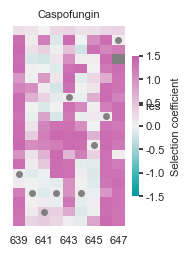

In [16]:
from matplotlib.ticker import MultipleLocator

# Convert conditions to title labels
title_dict = {'none':'Control',
              'dox':'Doxycycline control\n(Paralog repressed)',
              'anidulafungin':'Anidulafungin',
              'caspofungin':'Caspofungin',
              'micafungin':'Micafungin'
             }

# Purge graph space
sns.set(rc = {'figure.figsize':(1.8, 2.6),
              'font.size':8,
              'legend.title_fontsize':8, 'legend.fontsize':8,
              'axes.labelsize':8,'axes.titlesize':8,
              'xtick.labelsize':8, 'ytick.labelsize':8,
             },
       style='whitegrid')
f, ax = plt.subplots()

# Custom color palette
ccmap = sns.color_palette("blend:#009B9E,#42B7B9,#A7D3D4,#F1F1F1,#E4C1D9,#D691C1,#C75DAB", # CARTOColors Tropic
                          as_cmap=True)
ccmap.set_bad('.5') # Color for missing values

# Mask for missing values
mask = pd.isnull(wide_aa)

# Draw heatmap
ax = sns.heatmap(wide_aa, mask=mask, 
                 cmap=ccmap,
                 vmin=-1.5, center=0, vmax=1.5,
                 #xticklabels=len(wtaa)-1,
                 xticklabels=2,
                 yticklabels=False,
                 cbar_kws={'label':'Selection coefficient',
                           'shrink':.7
                          }
                )

ax.set_title(title_dict[compound])
ax.set(xlabel=None, ylabel=None)
ax.tick_params(axis='x', length=3)

cax = ax.figure.axes[-1]
cax.set_yticks([x for x in cax.get_yticks()]+[thresh], labels=[x for x in cax.get_yticks()]+[cax_label])
cax.tick_params(length=3, pad=2)

# Coordinates of WT protein sequence on the heatmap are extracted from the dataframe
# Coordinates should be OK even if the dataframe contains missing values
wtcoord_aa = [(i+0.5, list(aa_sort_order).index(v)+0.5) for i,v in enumerate(wtaa)]

for o in wtcoord_aa:
    ax.plot(o[0],o[1], marker='o', color='.5', markersize=4) # displays WT sequence

# Variants for which we inferred the DMS score
#estimate_coord = [(a+0.75-pos_offset[locus], list(aa_sort_order).index(b)+0.25) for a, b in zip(rescued_filtered.aa_pos, rescued_filtered.alt_aa)]

#for m in estimate_coord:
#    ax.plot(m[0],m[1], marker='*', color='.5', markersize=2)

# Graphs are output in the specified folder
plt.savefig(mgraph_outpath+cset_name+'_aa_heatmap_median_s.svg', format='svg', dpi=300)